# Matplotlib

## 1. Fundamentals

### Anatomy of a figure

In [14]:
import numpy as np
import matplotlib.pyplot as plt

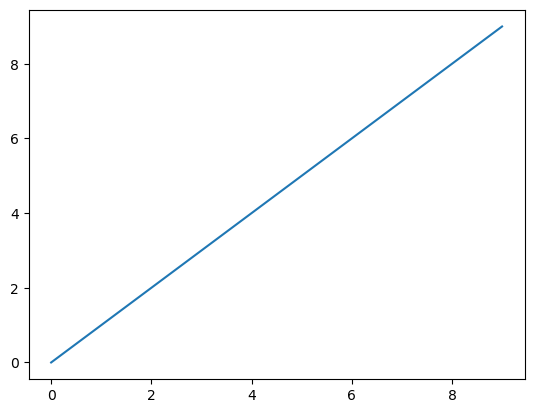

In [16]:
plt.plot(range(10))
plt.show()

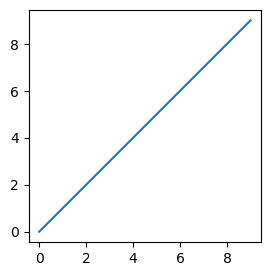

In [22]:
fig = plt.figure(figsize=(3,6))
ax = plt.subplot(aspect = 1)
ax.plot(range(10))
plt.show()

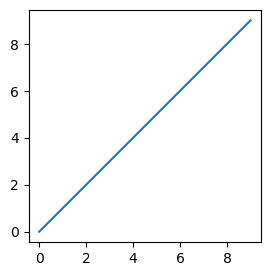

In [29]:
fig, ax = plt.subplots(figsize=(3,6), subplot_kw={"aspect":1})
ax.plot(range(10))

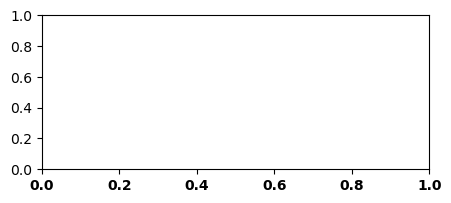

In [84]:
fig, ax = plt.subplots(figsize=(5,2))
for label in ax.get_xaxis().get_ticklabels():
    label.set_fontweight("bold")
    
plt.show()


In [86]:
import matplotlib
print(matplotlib.get_backend())

module://matplotlib_inline.backend_inline


In [115]:
# ----------------------------------------------------------------------------
# Title:   Scientific Visualisation - Python & Matplotlib
# Author:  Nicolas P. Rougier
# License: BSD
# ----------------------------------------------------------------------------
import numpy as np
matplotlib.use('webagg')
# %matplotlib inline
matplotlib.pyplot.rcdefaults()
import matplotlib.pyplot as plt
from matplotlib.figure import Figure
from matplotlib.backends.backend_agg import FigureCanvasAgg
from matplotlib.patches import Rectangle


def pixelated_text(dpi=100):
    fig = Figure(figsize=(1, 1), dpi=dpi)
    canvas, ax = FigureCanvasAgg(fig), fig.gca()
    ax.text(0.5, 0.5, "a", fontsize=75, ha="center", va="center")
    ax.axis("off")
    canvas.draw()
    image = np.frombuffer(canvas.tostring_argb(), dtype="uint8")
    image = image.reshape(dpi, dpi, 4)
    image = np.roll(image, 3, axis=2)
    return image


def square(position, size, edgecolor, facecolor, zorder):
    rect = Rectangle(
        position,
        size,
        size,
        transform=ax.transAxes,
        clip_on=False,
        zorder=zorder,
        linewidth=0.5,
        edgecolor=edgecolor,
        facecolor=facecolor,
    )
    ax.add_artist(rect)


image = pixelated_text(75)
fig = plt.figure(figsize=(4.25, 2), dpi=100)

# Left (raster)
ax = plt.subplot(
    1, 2, 1, frameon=False, aspect=1, xticks=[], yticks=[], xlim=[0, 1], ylim=[0, 1]
)

ax.imshow(image, extent=[0.1, 1.0, 0.1, 1.0], zorder=10, interpolation="nearest")
square((0.1, 0.1), 0.9, "black", "None", 20)

square((0.0, 0.0), 0.2, "black", "white", 20)
ax.imshow(image, extent=[0.0, 0.2, 0.0, 0.2], zorder=30, interpolation="nearest")
square((0.0, 0.0), 0.2, "black", "None", 40)

ax.text(0.55, 1.025, "Raster rendering", fontsize="small", ha="center", va="bottom")
ax.text(
    0.6, 0.1 - 0.025, ".PNG / .JPG / .TIFF", fontsize="x-small", ha="center", va="top"
)

# Right (vector)
ax = plt.subplot(
    1, 2, 2, frameon=False, aspect=1, xticks=[], yticks=[], xlim=[0, 1], ylim=[0, 1]
)
ax.text(0.55, 0.55, "a", fontsize=100, ha="center", va="center", color="#000099")
square((0.1, 0.1), 0.9, "#000099", "None", 20)
square((0.0, 0.0), 0.2, "#000099", "white", 20)
ax.text(
    0.1,
    0.1,
    "a",
    fontsize=22,
    ha="center",
    va="center",
    clip_on=False,
    zorder=30,
    color="#000099",
)
square((0.0, 0.0), 0.2, "#000099", "None", 40)

ax.text(
    0.55,
    1.025,
    "Vector rendering",
    fontsize="small",
    ha="center",
    va="bottom",
    color="#000099",
)
ax.text(
    0.6,
    0.1 - 0.025,
    ".PDF / .SVG / .PS",
    fontsize="x-small",
    ha="center",
    va="top",
    color="#000099",
)

""
plt.savefig("raster-vector.pdf", dpi=600)
plt.show()

In [110]:
matplotlib.pyplot.rcdefaults()

In [123]:
plt.ion() # Interactive mode on
plt.plot([1,2,3]) # Plot is shown
plt.xlabel("X Axis") # Label is updated
plt.ioff()
plt.show()

In [128]:
# matplotlib.use('webagg')\
%matplotlib inline

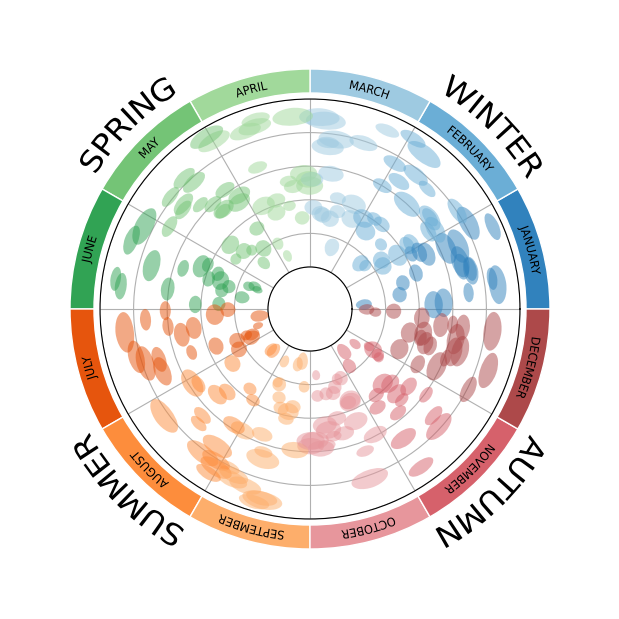

In [130]:
# -----------------------------------------------------------------------------
# Title:   Scientific Visualisation - Python & Matplotlib
# Author:  Nicolas P. Rougier
# License: BSD
# -----------------------------------------------------------------------------
# Illustrate the use of polar projection and rotated text (with transformation)
# -----------------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.textpath import TextPath
from matplotlib.patches import PathPatch
from matplotlib.patches import Ellipse

fig = plt.figure(figsize=(6, 6))
ax = fig.add_axes([0, 0, 1, 1], aspect=1)


size = 0.1
vals = np.ones(12)
np.random.seed(123)

# A nice set of colors for seasons
cmap20c = plt.get_cmap("tab20c")
cmap20b = plt.get_cmap("tab20b")
colors = [
    cmap20c(0),
    cmap20c(1),
    cmap20c(2),  # Winter
    cmap20c(10),
    cmap20c(9),
    cmap20c(8),  # Spring
    cmap20c(4),
    cmap20c(5),
    cmap20c(6),  # Summer
    cmap20b(15),
    cmap20b(14),
    cmap20b(13),
]  # Autumn

# Simple pie
ax.pie(np.ones(12), radius=1, colors=colors, wedgeprops=dict(width=size, edgecolor="w"))


# Rotated and transformed label
def label(text, angle, radius=1, scale=0.005):
    path = TextPath((0, 0), text, size=10)
    path.vertices.flags.writeable = True
    V = path.vertices
    xmin, xmax = V[:, 0].min(), V[:, 0].max()
    ymin, ymax = V[:, 1].min(), V[:, 1].max()
    V -= (xmin + xmax) / 2, (ymin + ymax) / 2
    V *= scale
    for i in range(len(V)):
        a = angle - V[i, 0]
        V[i, 0] = (radius + V[i, 1]) * np.cos(a)
        V[i, 1] = (radius + V[i, 1]) * np.sin(a)
    patch = PathPatch(path, facecolor="k", linewidth=0)
    ax.add_artist(patch)


# This could be made through a list but it is easier to red this way
label("JANUARY", 0.5 * 2 * np.pi / 12, 1 - 0.5 * size)
label("FEBRUARY", 1.5 * 2 * np.pi / 12, 1 - 0.5 * size)
label("MARCH", 2.5 * 2 * np.pi / 12, 1 - 0.5 * size)
label("WINTER", 1.5 * 2 * np.pi / 12, 1 + size, 0.0125)

label("APRIL", 3.5 * 2 * np.pi / 12, 1 - 0.5 * size)
label("MAY", 4.5 * 2 * np.pi / 12, 1 - 0.5 * size)
label("JUNE", 5.5 * 2 * np.pi / 12, 1 - 0.5 * size)
label("SPRING", 4.5 * 2 * np.pi / 12, 1 + size, 0.0125)

label("JULY", 6.5 * 2 * np.pi / 12, 1 - 0.5 * size)
label("AUGUST", 7.5 * 2 * np.pi / 12, 1 - 0.5 * size)
label("SEPTEMBER", 8.5 * 2 * np.pi / 12, 1 - 0.5 * size)
label("SUMMER", 7.5 * 2 * np.pi / 12, 1 + size, 0.0125)

label("OCTOBER", 9.5 * 2 * np.pi / 12, 1 - 0.5 * size)
label("NOVEMBER", 10.5 * 2 * np.pi / 12, 1 - 0.5 * size)
label("DECEMBER", 11.5 * 2 * np.pi / 12, 1 - 0.5 * size)
label("AUTUMN", 10.5 * 2 * np.pi / 12, 1 + size, 0.0125)


# Add a polar projection on top of the previous one
ax = fig.add_axes([0.15, 0.15, 0.7, 0.7], projection="polar")

# Some ellipses that will enforce polar projection
for i in range(250):
    p = np.random.uniform(0, 2 * np.pi), np.random.uniform(0.05, 0.95)
    w = h = 0.01 + 0.05 * np.random.uniform(1, 2)
    color = colors[int(np.floor((p[0] / (2 * np.pi)) * 12))]
    ellipse = Ellipse(
        p,
        width=2 * w,
        height=h,
        zorder=10,
        facecolor=color,
        edgecolor="none",
        alpha=0.5,
    )
    ax.add_artist(ellipse)
ax.set_xlim(0, 2 * np.pi)
ax.set_xticks(np.linspace(0, 2 * np.pi, 12, endpoint=False))
ax.set_xticklabels([])
ax.set_ylim(0, 1)
ax.set_yticks(np.linspace(0, 1, 6))
ax.set_yticklabels([])
ax.set_rorigin(-0.25)


# Save results and show it
plt.savefig("text-polar.pdf")
plt.show()

In [144]:
colors

[(0.19215686274509805, 0.5098039215686274, 0.7411764705882353, 1.0),
 (0.4196078431372549, 0.6823529411764706, 0.8392156862745098, 1.0),
 (0.6196078431372549, 0.792156862745098, 0.8823529411764706, 1.0),
 (0.6313725490196078, 0.8509803921568627, 0.6078431372549019, 1.0),
 (0.4549019607843137, 0.7686274509803922, 0.4627450980392157, 1.0),
 (0.19215686274509805, 0.6392156862745098, 0.32941176470588235, 1.0),
 (0.9019607843137255, 0.3333333333333333, 0.050980392156862744, 1.0),
 (0.9921568627450981, 0.5529411764705883, 0.23529411764705882, 1.0),
 (0.9921568627450981, 0.6823529411764706, 0.4196078431372549, 1.0),
 (0.9058823529411765, 0.5882352941176471, 0.611764705882353, 1.0),
 (0.8392156862745098, 0.3803921568627451, 0.4196078431372549, 1.0),
 (0.6784313725490196, 0.28627450980392155, 0.2901960784313726, 1.0)]

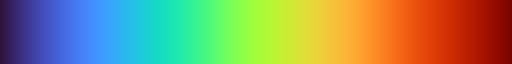

In [143]:
cmap20c = plt.get_cmap("turbo")
cmap20c